In [6]:
import glob 
import numpy as np

In [2]:
files=glob.glob("*/segments_log.txt")
len(files)

11

In [49]:
def extract_segs(filename):
    segs=[]

    with open(filename) as f:
        lines=f.readlines()
        
    lines=[line.strip() for line in lines[1:-1]]

    for line in lines:
        line=line[1:-1].split(",") 
        s,e,t=int(line[0]),int(line[1]), line[2].strip()[1:-1]
        # print(s,e,t)
        segs.append((s,e,t))
    return segs

In [51]:
filename=files[0]
segs=extract_segs(filename)
segs

[(12, 212, 'Eating'),
 (240, 440, 'Eating'),
 (744, 944, 'Eating'),
 (953, 1153, 'Eating'),
 (1164, 1364, 'Eating')]

In [143]:
def extract_p2s(filename, segs):
    file_p2s=filename.replace("segments_log.txt","p2s.txt")
    with open(file_p2s, 'r') as f:
        lines=f.readlines()
    

    segs_eating=[]
    segs_noneating=[]

    for si,ei,ti in segs:
        seg_is=lines[si:ei]
        # print('seg len', len(seg_is) )
        
        seg=[]
        for line in seg_is:
            se=line.strip().strip(',').split(',')
            if len(se)==1:
                continue
        
            xs=se[::2]
            ys=se[1::2]
            
            xs=[float(x) for x in xs]
            ys=[float(y) for y in ys]

            assert len(xs)==len(ys)
            vec=np.hstack([xs,ys])
            seg.append(vec)
        
        seg=np.array(seg)
        if seg.shape[0]<200:
            padding_needed=200-seg.shape[0]
            seg_padded_before=np.pad(seg, ((padding_needed, 0), (0, 0)), mode='constant')
            seg_padded_after=np.pad(seg, ((0, padding_needed), (0, 0)), mode='constant')
            if ti=='Eating':
                segs_eating.append(seg_padded_before)
                segs_eating.append(seg_padded_after)
            else:
                segs_noneating.append(seg_padded_before)
                segs_noneating.append(seg_padded_after)
        else:
            if ti=='Eating':
                segs_eating.append(seg)
            else:
                segs_noneating.append(seg)

    segs_eating=np.array(segs_eating)
    segs_noneating=np.array(segs_noneating)
    
 

    return segs_eating, segs_noneating

In [144]:
segs_eating, segs_noneating=extract_p2s(filename, segs)
len(segs_eating), len(segs_noneating)

(6, 0)

In [145]:
# segs_eating=np.array(segs_eating)
# segs_noneating=np.array(segs_noneating)

segs_eating.shape, segs_noneating.shape

((6, 200, 50), (0,))

In [146]:
eating_all=[]
noneating_all=[]

for filename in files:
    segs=extract_segs(filename)
    segs_eating, segs_noneating=extract_p2s(filename, segs)
    print(filename, segs_eating.shape, segs_noneating.shape)
    if len(segs_eating)>0:
        eating_all.extend(segs_eating)
    if len(segs_noneating)>0:
        noneating_all.extend(segs_noneating)
    
eating_all=np.array(eating_all)
noneating_all=np.array(noneating_all)

eating_all.shape, noneating_all.shape

10_08_2024_15_54_dain_kitchen/segments_log.txt (5, 200, 50) (0,)
10_08_2024_14_48_dain/segments_log.txt (5, 200, 50) (0,)
10_08_2024_15_04_mar/segments_log.txt (3, 200, 50) (0,)
10_08_2024_15_25_momotaz/segments_log.txt (3, 200, 50) (4, 200, 50)
10_04_2024_20_46_rosbag2_sajay_kitchen/segments_log.txt (4, 200, 50) (2, 200, 50)
10_04_2024_21_03_akash_kitchen/segments_log.txt (6, 200, 50) (0,)
10_08_2024_16_09_mar_kitchen/segments_log.txt (3, 200, 50) (0,)
10_08_2024_16_30_momotaz_kitchen2/segments_log.txt (2, 200, 50) (2, 200, 50)
10_08_2024_16_18_momotaz_kitchen/segments_log.txt (6, 200, 50) (2, 200, 50)
10_08_2024_15_37_momotaz2/segments_log.txt (2, 200, 50) (2, 200, 50)
10_04_2024_21_24_akash/segments_log.txt (6, 200, 50) (0,)


((45, 200, 50), (12, 200, 50))

In [147]:
X=np.vstack([eating_all, noneating_all])
y=np.hstack([np.ones(eating_all.shape[0]), np.zeros(noneating_all.shape[0])]) 

X.shape, y.shape

((57, 200, 50), (57,))

In [148]:
import numpy as np
import matplotlib.pyplot as plt
import glob 
import torch
import torch.nn as nn
import torch.optim as optim 
import time 

In [149]:
device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')
device 

device(type='cuda')

In [150]:
X=torch.from_numpy(X).float()
y=torch.from_numpy(y).reshape(-1,1)
X.shape, y.shape

(torch.Size([57, 200, 50]), torch.Size([57, 1]))

In [151]:
ids=np.arange(X.shape[0])
np.random.shuffle(ids)
train_ids=ids[:int(len(ids)*0.8)]
test_ids=ids[int(len(ids)*0.8):]
X_train, y_train=X[train_ids], y[train_ids]
X_test, y_test=X[test_ids], y[test_ids]

X_train.shape, y_train.shape, X_test.shape, y_test.shape

(torch.Size([45, 200, 50]),
 torch.Size([45, 1]),
 torch.Size([12, 200, 50]),
 torch.Size([12, 1]))

In [152]:
class LSTM(nn.Module):
    
    def __init__(self,input_dim,hidden_dim,output_dim,layer_num, seq_len):
        super(LSTM,self).__init__()
        self.hidden_dim = hidden_dim
        self.output_dim = output_dim
        self.lstm = torch.nn.LSTM(input_dim,hidden_dim,layer_num,batch_first=True)
        self.fc = torch.nn.Linear(hidden_dim,output_dim)
        self.bn = nn.BatchNorm1d(seq_len)
        
    def forward(self,inputs):
        x = self.bn(inputs)
        lstm_out,(hn,cn) = self.lstm(x)
        out = self.fc(lstm_out[:,-1,:])
        return out

In [153]:
import random
n_data_size_train = X_train.shape[0]
n_data_size_test = X_test.shape[0]

def randomTrainingExampleBatch(batch_size,flag,num=-1):
    if flag == 'train':
        X = X_train
        y = y_train
        data_size = n_data_size_train
    elif flag == 'test':
        X = X_test
        y = y_test
        data_size = n_data_size_test
    if num == -1:
        ran_num = random.randint(0,data_size-batch_size)
    else:
        ran_num = num
    pose_sequence_tensor = X[ran_num:(ran_num+batch_size)]
    pose_sequence_tensor = pose_sequence_tensor
    category_tensor = y[ran_num:ran_num+batch_size,:]
    return category_tensor.long(),pose_sequence_tensor

In [171]:
n_hidden = 128
n_joints = 25*2
n_categories = 2
n_layer = 3
seq_len = 200
rnn = LSTM(n_joints,n_hidden,n_categories,n_layer, seq_len)
rnn.to(device)

LSTM(
  (lstm): LSTM(50, 128, num_layers=3, batch_first=True)
  (fc): Linear(in_features=128, out_features=2, bias=True)
  (bn): BatchNorm1d(200, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
)

In [172]:
criterion = nn.CrossEntropyLoss()
learning_rate = 1e-5
# optimizer = optim.SGD(rnn.parameters(),lr=learning_rate,momentum=0.9)

optimizer = optim.Adam(rnn.parameters(),lr=learning_rate)

In [173]:
n_iters = 20_000
print_every = 1000
plot_every = 1000
batch_size = 4

current_loss = 0
all_losses = []

 
start = time.time()

for iter in range(1, n_iters + 1):
   
    category_tensor, input_sequence = randomTrainingExampleBatch(batch_size,'train')
    input_sequence = input_sequence.to(device)
    category_tensor = category_tensor.to(device)
    category_tensor = torch.squeeze(category_tensor)
    
    optimizer.zero_grad()
    
    output = rnn(input_sequence)
    loss = criterion(output, category_tensor)
    loss.backward()
    optimizer.step() 
 
    current_loss += loss.item()

    if iter % print_every == 0:
        print('iter: %d, loss: %.3f' % (iter, loss.item()))
    
    
    # Add current loss avg to list of losses
    if iter % plot_every == 0:
        all_losses.append(current_loss / plot_every)
        current_loss = 0

iter: 1000, loss: 0.206
iter: 2000, loss: 0.001
iter: 3000, loss: 0.001
iter: 4000, loss: 0.011
iter: 5000, loss: 0.220
iter: 6000, loss: 0.000
iter: 7000, loss: 0.000
iter: 8000, loss: 0.339
iter: 9000, loss: 0.348
iter: 10000, loss: 0.164
iter: 11000, loss: 0.000
iter: 12000, loss: 0.000
iter: 13000, loss: 0.173
iter: 14000, loss: 0.000
iter: 15000, loss: 0.001
iter: 16000, loss: 0.000
iter: 17000, loss: 0.000
iter: 18000, loss: 0.000
iter: 19000, loss: 0.103
iter: 20000, loss: 0.000


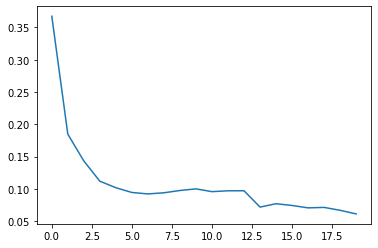

In [174]:
plt.plot(all_losses)

In [175]:
#test 

rnn.eval()

n_correct = 0
n_total = 0
for i in range(n_data_size_test):
    category_tensor, input_sequence = randomTrainingExampleBatch(1,'test',i)
    input_sequence = input_sequence.to(device)
    category_tensor = category_tensor.to(device)
    category_tensor = torch.squeeze(category_tensor)
    output = rnn(input_sequence)
    po=output.argmax(axis=1)
    guess=po.item()
    category = category_tensor
    if category == guess:
        n_correct += 1
    n_total += 1

print('Accuracy of %d test data: %.3f%%' % (n_data_size_test, n_correct / n_total * 100))

Accuracy of 12 test data: 75.000%


In [176]:
#train

rnn.eval()

n_correct = 0
n_total = 0
for i in range(n_data_size_test):
    category_tensor, input_sequence = randomTrainingExampleBatch(1,'train',i)
    input_sequence = input_sequence.to(device)
    category_tensor = category_tensor.to(device)
    category_tensor = torch.squeeze(category_tensor)
    output = rnn(input_sequence)
    po=output.argmax(axis=1)
    guess=po.item()
    category = category_tensor
    if category == guess:
        n_correct += 1
    n_total += 1

print('Accuracy of %d test data: %.3f%%' % (n_data_size_test, n_correct / n_total * 100))

Accuracy of 12 test data: 91.667%
